*TO DO*
- ord one hot na Y, four g, wifi, blue *DONE*
- skalowanie? *DONE???*
- model *DONE*
- stratify *DONE*
- random state??? *DONE*
- poprawki modelu (warstwy, early stopping *done*, dropout *done*, activation func *done*)
- Testy modelu *DONE???*

In [3743]:
import pandas as pd
import keras
import sklearn as sk
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Wczytanie danych

In [3744]:
phone_data = pd.read_csv("dataset.csv")

In [3745]:
phone_data.head()

,Unnamed: 0,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,0,842,no,2.2,0,1,no,7,0.6,188,...,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1,1021,yes,0.5,1,0,yes,53,0.7,136,...,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,2,563,yes,0.5,1,2,yes,41,0.9,145,...,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,3,615,yes,2.5,0,0,no,10,0.8,131,...,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,4,1821,yes,1.2,0,13,yes,44,0.6,141,...,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost


In [3746]:
phone_data['price_range'].value_counts()

price_range
low cost          485
high cost         484
medium cost       483
very high cost    483
Name: count, dtype: int64

In [3747]:
phone_data.describe()

,Unnamed: 0,battery_power,clock_speed,dual_sim,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen
count,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1913.000000,1935.000000,1935.000000,1873.000000,1935.000000,1935.000000
mean,997.788114,1240.282687,1.528889,0.509044,4.298708,32.115245,0.504703,140.209819,4.529716,9.932817,646.829457,1255.708527,2120.500784,12.322997,5.757623,10.998398,0.762274,0.501809
std,577.034770,438.590972,0.820332,0.500047,4.345792,18.161480,0.292660,35.480487,2.285474,6.057774,445.042126,434.465962,1083.400626,4.209676,4.333399,5.457734,0.425801,0.500126
min,0.000000,501.000000,0.500000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000
25%,499.500000,853.500000,0.700000,0.000000,1.000000,16.000000,0.200000,109.000000,3.000000,5.000000,284.500000,880.000000,1205.000000,9.000000,2.000000,6.000000,1.000000,0.000000
50%,999.000000,1231.000000,1.500000,1.000000,3.000000,32.000000,0.500000,141.000000,4.000000,10.000000,567.000000,1251.000000,2131.000000,12.000000,5.000000,11.000000,1.000000,1.000000
75%,1493.500000,1617.000000,2.250000,1.000000,7.000000,48.000000,0.800000,170.000000,7.000000,15.000000,948.000000,1638.500000,3056.000000,16.000000,9.000000,16.000000,1.000000,1.000000
max,1999.000000,1998.000000,4.000000,1.000000,19.000000,64.000000,2.000000,200.000000,8.000000,20.000000,1960.000000,2298.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000


# Preprocessing

In [3748]:
phone_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1935 non-null   int64  
 1   battery_power  1935 non-null   int64  
 2   blue           1915 non-null   object 
 3   clock_speed    1935 non-null   float64
 4   dual_sim       1935 non-null   int64  
 5   fc             1935 non-null   int64  
 6   four_g         1935 non-null   object 
 7   int_memory     1935 non-null   int64  
 8   m_dep          1935 non-null   float64
 9   mobile_wt      1935 non-null   int64  
 10  n_cores        1935 non-null   int64  
 11  pc             1935 non-null   int64  
 12  px_height      1935 non-null   int64  
 13  px_width       1935 non-null   int64  
 14  ram            1913 non-null   float64
 15  sc_h           1935 non-null   int64  
 16  sc_w           1935 non-null   int64  
 17  talk_time      1873 non-null   float64
 18  three_g 

In [3749]:
display(phone_data)

,Unnamed: 0,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,0,842,no,2.2,0,1,no,7,0.6,188,...,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1,1021,yes,0.5,1,0,yes,53,0.7,136,...,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,2,563,yes,0.5,1,2,yes,41,0.9,145,...,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,3,615,yes,2.5,0,0,no,10,0.8,131,...,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,4,1821,yes,1.2,0,13,yes,44,0.6,141,...,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,1995,794,yes,0.5,1,0,yes,2,0.8,106,...,1222,1890,668.0,13,4,19.0,1,1,no_wifi,low cost
1931,1996,1965,yes,2.6,1,0,no,39,0.2,187,...,915,1965,2032.0,11,10,16.0,1,1,wifi,high cost
1932,1997,1911,no,0.9,1,1,yes,36,0.7,108,...,868,1632,3057.0,9,1,5.0,1,1,no_wifi,very high cost
1933,1998,1512,no,0.9,0,4,yes,46,0.1,145,...,336,670,869.0,18,10,19.0,1,1,wifi,low cost


## Usuwanie wierszy z nadmierną ilością nanów

In [3750]:
def remove_nan(data, threshold=0.5):
    nan_df = data.isna()
    missing_val_row_percent = nan_df.mean(axis=1)
    return data[missing_val_row_percent <= threshold]

In [3751]:
phone_data = remove_nan(phone_data)

## Pipeline

In [3752]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [3753]:
text_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(sparse_output=False))
])

In [3754]:
number_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [3755]:
label_pipeline = Pipeline([
    ("ord", OrdinalEncoder(categories=[["low cost", "medium cost", "high cost", "very high cost"]]))
])

## Podział na cechy i etykiety

In [3756]:
X = phone_data.drop(["price_range", "Unnamed: 0"], axis=1)
Y = pd.DataFrame(phone_data["price_range"])

## Column Transformers

In [3757]:
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_columns)

['battery_power', 'clock_speed', 'dual_sim', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen']


In [3758]:
ct_1 = ColumnTransformer([
    ("text_pipe", text_pipeline, ["blue", "four_g", "wifi"]),
    ("number_pipe", number_pipeline, numeric_columns)
])

In [3759]:
ct_2 = ColumnTransformer([
    ("ord", label_pipeline, ["price_range"]),
])

## Wykonanie

In [3760]:
X_prepro = pd.DataFrame(ct_1.fit_transform(X), columns=ct_1.get_feature_names_out())

In [3761]:
Y_prepro = pd.DataFrame(ct_2.fit_transform(Y), columns=ct_2.get_feature_names_out())

In [3762]:
X_prepro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   text_pipe__blue_no          1935 non-null   float64
 1   text_pipe__blue_yes         1935 non-null   float64
 2   text_pipe__four_g_no        1935 non-null   float64
 3   text_pipe__four_g_yes       1935 non-null   float64
 4   text_pipe__wifi_no_wifi     1935 non-null   float64
 5   text_pipe__wifi_wifi        1935 non-null   float64
 6   number_pipe__battery_power  1935 non-null   float64
 7   number_pipe__clock_speed    1935 non-null   float64
 8   number_pipe__dual_sim       1935 non-null   float64
 9   number_pipe__fc             1935 non-null   float64
 10  number_pipe__int_memory     1935 non-null   float64
 11  number_pipe__m_dep          1935 non-null   float64
 12  number_pipe__mobile_wt      1935 non-null   float64
 13  number_pipe__n_cores        1935 

In [3763]:
display(X_prepro)

,text_pipe__blue_no,text_pipe__blue_yes,text_pipe__four_g_no,text_pipe__four_g_yes,text_pipe__wifi_no_wifi,text_pipe__wifi_wifi,number_pipe__battery_power,number_pipe__clock_speed,number_pipe__dual_sim,number_pipe__fc,...,number_pipe__n_cores,number_pipe__pc,number_pipe__px_height,number_pipe__px_width,number_pipe__ram,number_pipe__sc_h,number_pipe__sc_w,number_pipe__talk_time,number_pipe__three_g,number_pipe__touch_screen
0,1.0,0.0,1.0,0.0,0.0,1.0,-0.908331,0.818308,-1.018254,-0.759254,...,-1.107153,-1.309865,-1.408836,-1.150465,0.397885,-0.789575,0.286772,1.490569,-1.790676,-1.003624
1,0.0,1.0,0.0,1.0,1.0,0.0,-0.500100,-1.254559,0.982073,-0.989421,...,-0.669494,-0.649386,0.580254,1.685934,0.474026,1.111300,-0.636529,-0.744837,0.558448,0.996389
2,0.0,1.0,0.0,1.0,1.0,0.0,-1.544623,-1.254559,0.982073,-0.529087,...,0.205824,-0.649386,1.384880,1.059716,0.448027,-0.314357,-0.867355,-0.372269,0.558448,0.996389
3,0.0,1.0,1.0,0.0,1.0,0.0,-1.426031,1.184108,-1.018254,-0.989421,...,0.643483,-0.154026,1.279244,1.220875,0.602167,0.873690,0.517598,0.000298,0.558448,-1.003624
4,0.0,1.0,0.0,1.0,1.0,0.0,1.324394,-0.401025,-1.018254,2.002751,...,-1.107153,0.671573,1.261264,-0.100629,-0.658810,-1.027185,-0.867355,0.745434,0.558448,0.996389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,0.0,1.0,0.0,1.0,1.0,0.0,-1.017800,-1.254559,0.982073,-0.989421,...,0.643483,0.671573,1.292730,1.460311,-1.348726,0.160862,-0.405704,1.490569,0.558448,0.996389
1931,0.0,1.0,1.0,0.0,0.0,1.0,1.652803,1.306042,0.982073,-0.989421,...,-0.231835,-1.144745,0.602729,1.632981,-0.082178,-0.314357,0.979248,0.931718,0.558448,0.996389
1932,1.0,0.0,0.0,1.0,1.0,0.0,1.529650,-0.766825,0.982073,-0.759254,...,1.518801,-1.144745,0.497094,0.866325,0.869591,-0.789575,-1.098180,-1.117405,0.558448,0.996389
1933,1.0,0.0,0.0,1.0,0.0,1.0,0.619683,-0.766825,-1.018254,-0.068753,...,0.205824,-0.814506,-0.698608,-1.348460,-1.162087,1.348909,0.979248,1.490569,0.558448,0.996389


In [3764]:
Y_prepro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ord__price_range  1935 non-null   float64
dtypes: float64(1)
memory usage: 15.2 KB


In [3765]:
display(Y_prepro)

,ord__price_range
0,1.0
1,2.0
2,2.0
3,2.0
4,1.0
...,...
1930,0.0
1931,2.0
1932,3.0
1933,0.0


# Podział na zbiory

In [3766]:
from sklearn.model_selection import train_test_split

In [3767]:
print(type(Y_prepro))

<class 'pandas.core.frame.DataFrame'>


In [3768]:
X_train, X_temp, Y_train, Y_temp = train_test_split(X_prepro, Y_prepro, test_size=0.3, stratify=Y_prepro,  random_state=42)

In [3769]:
X_valid, X_test, Y_valid, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, stratify=Y_temp,  random_state=42)

In [3770]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1354 entries, 1024 to 119
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   text_pipe__blue_no          1354 non-null   float64
 1   text_pipe__blue_yes         1354 non-null   float64
 2   text_pipe__four_g_no        1354 non-null   float64
 3   text_pipe__four_g_yes       1354 non-null   float64
 4   text_pipe__wifi_no_wifi     1354 non-null   float64
 5   text_pipe__wifi_wifi        1354 non-null   float64
 6   number_pipe__battery_power  1354 non-null   float64
 7   number_pipe__clock_speed    1354 non-null   float64
 8   number_pipe__dual_sim       1354 non-null   float64
 9   number_pipe__fc             1354 non-null   float64
 10  number_pipe__int_memory     1354 non-null   float64
 11  number_pipe__m_dep          1354 non-null   float64
 12  number_pipe__mobile_wt      1354 non-null   float64
 13  number_pipe__n_cores        1354 non

In [3771]:
Y_train['ord__price_range'].value_counts()

ord__price_range
2.0    339
0.0    339
3.0    338
1.0    338
Name: count, dtype: int64

In [3772]:
Y_test['ord__price_range'].value_counts()

ord__price_range
2.0    73
3.0    73
0.0    73
1.0    72
Name: count, dtype: int64

In [3773]:
Y_valid['ord__price_range'].value_counts()

ord__price_range
0.0    73
1.0    73
3.0    72
2.0    72
Name: count, dtype: int64

In [3774]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 539 to 229
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   text_pipe__blue_no          291 non-null    float64
 1   text_pipe__blue_yes         291 non-null    float64
 2   text_pipe__four_g_no        291 non-null    float64
 3   text_pipe__four_g_yes       291 non-null    float64
 4   text_pipe__wifi_no_wifi     291 non-null    float64
 5   text_pipe__wifi_wifi        291 non-null    float64
 6   number_pipe__battery_power  291 non-null    float64
 7   number_pipe__clock_speed    291 non-null    float64
 8   number_pipe__dual_sim       291 non-null    float64
 9   number_pipe__fc             291 non-null    float64
 10  number_pipe__int_memory     291 non-null    float64
 11  number_pipe__m_dep          291 non-null    float64
 12  number_pipe__mobile_wt      291 non-null    float64
 13  number_pipe__n_cores        291 non-nu

In [3775]:
X_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 1786 to 547
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   text_pipe__blue_no          290 non-null    float64
 1   text_pipe__blue_yes         290 non-null    float64
 2   text_pipe__four_g_no        290 non-null    float64
 3   text_pipe__four_g_yes       290 non-null    float64
 4   text_pipe__wifi_no_wifi     290 non-null    float64
 5   text_pipe__wifi_wifi        290 non-null    float64
 6   number_pipe__battery_power  290 non-null    float64
 7   number_pipe__clock_speed    290 non-null    float64
 8   number_pipe__dual_sim       290 non-null    float64
 9   number_pipe__fc             290 non-null    float64
 10  number_pipe__int_memory     290 non-null    float64
 11  number_pipe__m_dep          290 non-null    float64
 12  number_pipe__mobile_wt      290 non-null    float64
 13  number_pipe__n_cores        290 non-n

# Sieć Neuronowa

In [3776]:
n_input_features = X_train.shape[1]
n_classes = len(np.unique(Y))

In [ ]:
model = keras.Sequential([
    keras.layers.Input((n_input_features,)),
    keras.layers.Dense(64, activation="sigmoid"),
    # keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="sigmoid"),
    # keras.layers.Dropout(0.3),
    # keras.layers.Dense(100, activation="relu"),
    # keras.layers.Dropout(0.3),
    keras.layers.Dense(n_classes, activation="softmax")
])

In [3778]:
model.summary()

Model: "sequential_78"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_284 (Dense)               │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_285 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_286 (Dense)               │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_287 (Dense)               │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,600 (49.22 KB)

 Trainable params: 12,600 (49.22 KB)

 Non-trainable params: 0 (0.00 B)

In [3779]:
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [3780]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

## Uczenie

In [3781]:
history = model.fit(X_train, Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2755 - loss: 1.3840 - val_accuracy: 0.3828 - val_loss: 1.3730
Epoch 2/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3257 - loss: 1.3722 - val_accuracy: 0.5172 - val_loss: 1.3557
Epoch 3/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4247 - loss: 1.3467 - val_accuracy: 0.4931 - val_loss: 1.3299
Epoch 4/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5089 - loss: 1.3108 - val_accuracy: 0.5897 - val_loss: 1.2778
Epoch 5/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5635 - loss: 1.2439 - val_accuracy: 0.5276 - val_loss: 1.2003
Epoch 6/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5657 - loss: 1.1383 - val_accuracy: 0.6759 - val_loss: 1.0690
Epoch 7/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6883 - loss: 0.9977 - val_accuracy: 0.7310 - val_loss: 0.9195
Epoch 8/200
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7622 - loss: 0.8512 - val_accuracy: 0.8310 - v

## Historia 

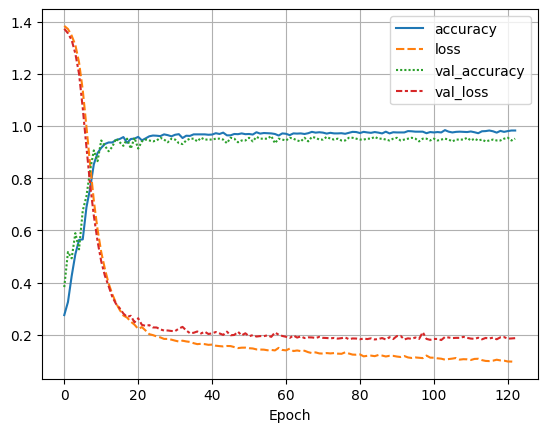

In [3782]:
def display_history(history):
    sns.lineplot(history.history)
    plt.grid()
    plt.xlabel("Epoch")

display_history(history)

In [3793]:
model_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [3794]:
model_predictions = np.argmax(model_predictions, axis=1)

## Sprawdzamy kilka pierwszych

In [3795]:
display(model_predictions[:10])

array([2, 1, 2, 1, 2, 3, 2, 3, 0, 1])

In [3796]:
Y_test[:10]

,ord__price_range
539,2.0
244,1.0
1567,2.0
1108,1.0
545,2.0
724,3.0
1526,2.0
1241,3.0
1346,0.0
949,3.0


# Testy

In [3787]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

## Accuracy

In [3791]:
print("Train acc:", history.history['accuracy'][-1])
print("Val acc:", history.history['val_accuracy'][-1])
print("Test acc:", accuracy_score(Y_test.values, model_predictions))

Train acc: 0.9830132722854614
Val acc: 0.951724112033844
Test acc: 0.9381443298969072


## Confusion Matrix

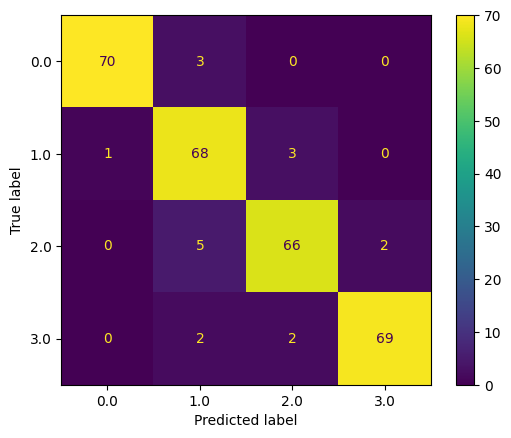

In [3789]:
ConfusionMatrixDisplay.from_predictions(Y_test, model_predictions)

## Recall, Precisionm, F1

In [3790]:
print(classification_report(Y_test, model_predictions, target_names=["low cost", "medium cost", "high cost", "very high cost"]))

                precision    recall  f1-score   support

      low cost       0.99      0.96      0.97        73
   medium cost       0.87      0.94      0.91        72
     high cost       0.93      0.90      0.92        73
very high cost       0.97      0.95      0.96        73

      accuracy                           0.94       291
     macro avg       0.94      0.94      0.94       291
  weighted avg       0.94      0.94      0.94       291

